# Notebook to compare different loss functions with the same starting model

In [1]:
import torch
import matplotlib.pyplot as plt
from scipy.signal import butter
from torchaudio.functional import biquad
import deepwave
from deepwave import scalar
from scipy.ndimage import gaussian_filter
import numpy as np

In [ ]:
import os, sys
sys.path.insert(0, os.path.expanduser("../quick_start"))
from plotting import plot3d

In [ ]:
# 1. Setup
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

nz, ny, nx = 96, 96, 96

file = "../allmodels/model_9999/vp3d.bin"
v_true = np.memmap(
    file,
    dtype=np.float32,
    mode='r+',
    shape=(nx, ny, nz)
).T

v_true_tensor = torch.from_numpy(v_true).to(device)

dz, dy, dx = 10.0, 10.0, 10.0
nt, dt = 501, 0.002
freq = 25.0 # Max frequency for wavelet
peak_time = 1.5 / freq


In [ ]:
# 2. Model & Constraints
class Model(torch.nn.Module):
    def __init__(self, initial, min_vel, max_vel):
        super().__init__()
        self.min_vel, self.max_vel = min_vel, max_vel
        
        # 1. Normalize the initial velocity to the [0, 1] range
        normalized = (initial - min_vel) / (max_vel - min_vel)
        
        # 2. CLAMP the values to be strictly inside (0, 1) 
        # This prevents logit(0) = -Inf and logit(1) = Inf
        safe_normalized = torch.clamp(normalized, min=1e-4, max=1.0 - 1e-4)
        
        # 3. Apply logit safely
        self.model = torch.nn.Parameter(torch.logit(safe_normalized))

    def forward(self):
        return torch.sigmoid(self.model) * (self.max_vel - self.min_vel) + self.min_vel

v_init = gaussian_filter(v_true, sigma=5, radius=5)
v_init_tensor = torch.from_numpy(v_init).to(device)

model = Model(v_init_tensor, 1200.0, 4000.0).to(device)

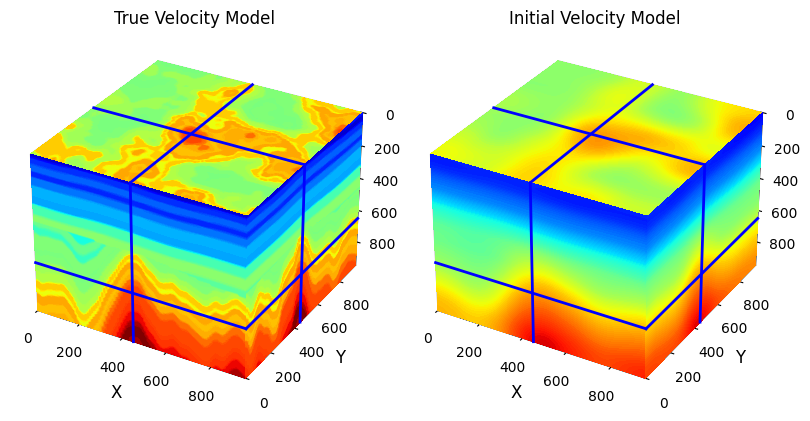

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), subplot_kw = {"projection": "3d"}, constrained_layout=True)
plt.sca(ax[0])

frames = [65, 45, 45]
plot3d(
    v_true,
    cmap = "jet",
    vmin = 1500, vmax = 4000,
    ifnewfig=False,
    ifinside=False,
    showf=False,
    close=False,
    frames = frames,
    dx=10.0, dy=10.0, dz=10.0
)

ax[0].set_title("True Velocity Model")

plt.sca(ax[1])
plot3d(
    # v_init,
    model().detach().cpu().numpy(),
    cmap = "jet",
    vmin = 1500, vmax = 4000,
    dx=10.0, dy=10.0, dz=10.0,
    ifnewfig=False,
    ifinside=False,
    showf=False,
    close=False,
    frames = frames,
)
ax[1].set_title("Initial Velocity Model")

plt.show()


In [6]:
s_coords_y = torch.linspace(5, ny-6, 6).long()
s_coords_x = torch.linspace(5, nx-6, 6).long()
n_shots = len(s_coords_y) * len(s_coords_x)
sy, sx = torch.meshgrid(s_coords_y, s_coords_x, indexing='ij')
source_locations = torch.zeros(n_shots, 1, 3, dtype=torch.long, device=device)
source_locations[:, 0, 0] = 1 
source_locations[:, 0, 1] = sy.flatten()
source_locations[:, 0, 2] = sx.flatten()

receiver_locations = torch.zeros(n_shots, ny * nx, 3, dtype=torch.long, device=device)
ry, rx = torch.meshgrid(torch.arange(ny).long(), torch.arange(nx).long(), indexing='ij')
receiver_locations[..., 0] = 1
receiver_locations[:, :, 1] = ry.flatten().to(device)
receiver_locations[:, :, 2] = rx.flatten().to(device)

source_amplitudes = deepwave.wavelets.ricker(freq, nt, dt, peak_time).repeat(n_shots, 1, 1).to(device)

pml_width = [0, 20, 20, 20, 20, 20] # free surface

In [7]:
def taper(x):
    return deepwave.common.cosine_taper_end(x, 50)

def get_filter(cutoff, dt, device):
    sos = butter(4, cutoff, fs=1/dt, output="sos")
    return [torch.from_numpy(s).to(device).to(torch.float32) for s in sos]

def apply_filt(x, sos_list):
    for s in sos_list:
        x = biquad(x, s[0], s[1], s[2], s[3], s[4], s[5])
    return x



In [9]:
with torch.no_grad():
    observed_data = scalar(
                        v_true_tensor, (dz, dy, dx), dt,      
                        source_amplitudes=source_amplitudes,
                        source_locations=source_locations, receiver_locations=receiver_locations,
                        pml_freq=freq, pml_width=pml_width,
    )[-1]
observed_data = taper(observed_data)

In [10]:
observed_data_cpu = observed_data.cpu().numpy()
del observed_data
torch.cuda.empty_cache()

Starting multiscale FWI — 4 models in parallel:
   envelope, l1, l2, l2_tv

--- 10 Hz band ---
  step  0 | envelope: 1.7009 | l1: 448.1443 | l2: 1.4794 | l2_tv: 1.7322
  step  1 | envelope: 1.5923 | l1: 424.9370 | l2: 1.3639 | l2_tv: 1.6323
  step  2 | envelope: 1.4790 | l1: 402.1420 | l2: 1.2526 | l2_tv: 1.5304
  step  3 | envelope: 1.3655 | l1: 379.8036 | l2: 1.1458 | l2_tv: 1.4304
  step  4 | envelope: 1.2548 | l1: 357.9179 | l2: 1.0440 | l2_tv: 1.3361
  step  5 | envelope: 1.1491 | l1: 336.4861 | l2: 0.9474 | l2_tv: 1.2456
  step  6 | envelope: 1.0496 | l1: 315.5503 | l2: 0.8564 | l2_tv: 1.1595
  step  7 | envelope: 0.9574 | l1: 295.1933 | l2: 0.7711 | l2_tv: 1.0789
  step  8 | envelope: 0.8729 | l1: 275.4980 | l2: 0.6919 | l2_tv: 1.0037
  step  9 | envelope: 0.7963 | l1: 256.5446 | l2: 0.6188 | l2_tv: 0.9338
  step 10 | envelope: 0.7274 | l1: 238.4388 | l2: 0.5518 | l2_tv: 0.8694
  step 11 | envelope: 0.6658 | l1: 221.3483 | l2: 0.4910 | l2_tv: 0.8106
  step 12 | envelope: 0.6110 

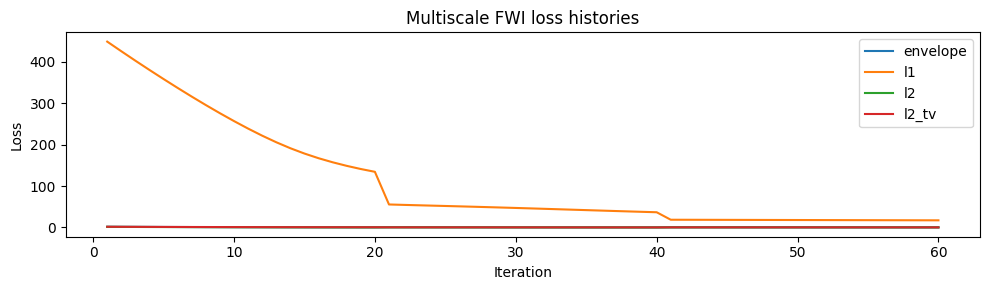

In [11]:
torch.cuda.empty_cache()

# ==========================================
# 1. Loss functions
# ==========================================
def envelope_loss(pred, target):
    """MSE between analytic-signal envelopes (time axis = last dim)."""
    def get_envelope(x):
        Xf = torch.fft.fft(x, dim=-1)
        n = Xf.shape[-1]
        h = torch.zeros_like(Xf)
        if n % 2 == 0:
            h[..., 0] = 1
            h[..., n // 2] = 1
            h[..., 1 : n // 2] = 2
        else:
            h[..., 0] = 1
            h[..., 1 : (n + 1) // 2] = 2
        x_analytic = torch.fft.ifft(Xf * h, dim=-1)
        return torch.abs(x_analytic)

    return torch.nn.MSELoss()(get_envelope(pred), get_envelope(target))


def total_variation_loss(v, weight=1.0):
    """Isotropic TV on the 3D velocity volume (nz, ny, nx)."""
    tv = torch.abs(v[1:, :, :] - v[:-1, :, :]).mean()
    tv = tv + torch.abs(v[:, 1:, :] - v[:, :-1, :]).mean()
    tv = tv + torch.abs(v[:, :, 1:] - v[:, :, :-1]).mean()
    return weight * tv


def data_loss(loss_key, pred, target):
    if loss_key == "l2":
        return torch.nn.MSELoss()(pred, target)
    if loss_key == "l1":
        return torch.nn.L1Loss()(pred, target)
    if loss_key == "envelope":
        return envelope_loss(pred, target)
    raise ValueError(f"Unknown loss_key: {loss_key}")


# ==========================================
# 2. Four FWI runs in one multiscale schedule
# ==========================================
# Each entry: (storage key, data-loss key, add TV on velocity)
LOSS_RUNS = [
    ("envelope", "envelope", False),
    ("l1", "l1", False),
    ("l2", "l2", False),
    ("l2_tv", "l2", True),
]

tv_weight = 1e-8  # weight on TV term (tune if L2+TV is too smooth / too rough)

loss_multiplier = 1e6
n_shots_per_batch = 2
n_batch = (n_shots + n_shots_per_batch - 1) // n_shots_per_batch
learning_rate = 1e-2

fwi_models = {}
fwi_optimizers = {}
loss_histories = {name: [] for name, _, _ in LOSS_RUNS}

for name, _, _ in LOSS_RUNS:
    fwi_models[name] = Model(v_init_tensor, 1200.0, 4000.0).to(device)
    fwi_optimizers[name] = torch.optim.Adam(fwi_models[name].parameters(), lr=learning_rate)

print("Starting multiscale FWI — 4 models in parallel:")
print("  ", ", ".join(n for n, _, _ in LOSS_RUNS))

for cutoff in [10, 15, 25]:
    print(f"\n--- {cutoff} Hz band ---")

    if cutoff == 10:
        learning_rate = 1e-2
        loss_multiplier = 1e6
    elif cutoff == 15:
        learning_rate = 5e-3
        loss_multiplier = 1e5
    else:
        learning_rate = 1e-3
        loss_multiplier = 1e4

    for opt in fwi_optimizers.values():
        opt.param_groups[0]["lr"] = learning_rate

    sos = get_filter(cutoff, dt, device)
    obs_filt_cpu = apply_filt(
        torch.from_numpy(observed_data_cpu).to(device), sos
    ).cpu().detach().numpy()

    for i in range(20):
        for opt in fwi_optimizers.values():
            opt.zero_grad()

        epoch_losses = {name: 0.0 for name, _, _ in LOSS_RUNS}

        for batch in range(n_batch):
            batch_start = batch * n_shots_per_batch
            batch_end = min(batch_start + n_shots_per_batch, n_shots)
            s = slice(batch_start, batch_end)
            obs_filt = torch.from_numpy(obs_filt_cpu[s]).to(device)

            for name, loss_key, use_tv in LOSS_RUNS:
                v = fwi_models[name]()
                out = scalar(
                    v,
                    (dz, dy, dx),
                    dt,
                    source_amplitudes=source_amplitudes[s],
                    source_locations=source_locations[s],
                    receiver_locations=receiver_locations[s],
                    pml_freq=freq,
                    pml_width=pml_width,
                    storage_mode="device",
                )[-1]
                out_filt = apply_filt(taper(out), sos)

                raw_loss = data_loss(loss_key, out_filt, obs_filt)
                if use_tv:
                    raw_loss = raw_loss + total_variation_loss(v, weight=tv_weight)

                loss = raw_loss * loss_multiplier
                (loss / n_batch).backward()
                epoch_losses[name] += loss.item()

        for name, opt in fwi_optimizers.items():
            opt.step()

        msg = " | ".join(f"{n}: {epoch_losses[n] / n_batch:.4f}" for n, _, _ in LOSS_RUNS)
        print(f"  step {i:2d} | {msg}")
        for name, _, _ in LOSS_RUNS:
            loss_histories[name].append(epoch_losses[name] / n_batch)

# Final velocity models (numpy)
v_final = {}
with torch.no_grad():
    for name, _, _ in LOSS_RUNS:
        v_final[name] = fwi_models[name]().detach().cpu().numpy()

del out, obs_filt, out_filt, v, s, batch_start, batch_end, loss, epoch_losses
torch.cuda.empty_cache()

# Loss curves
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
for name, _, _ in LOSS_RUNS:
    ax.plot(range(1, len(loss_histories[name]) + 1), loss_histories[name], label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Multiscale FWI loss histories")
ax.legend()
plt.tight_layout()
plt.show()


In [73]:
arrays_to_save = {
    "v_init": v_init,
    "v_true": v_true,
    "v_final_envelope": v_final["envelope"],
    "v_final_l1": v_final["l1"],
    "v_final_l2": v_final["l2"],
    "v_final_l2_tv": v_final["l2_tv"],
}

np.savez("model9999_fwi_all.npz", **arrays_to_save)


In [13]:
print(f"{'':12s}  {'MAE':>10s}  {'RMSE':>10s}")
print(f"{'initial':12s}  {np.abs(v_init - v_true).mean():10.2f}  {np.sqrt(np.mean((v_init - v_true) ** 2)):10.2f}")
for name in ["envelope", "l1", "l2", "l2_tv"]:
    vf = v_final[name]
    mae = np.abs(vf - v_true).mean()
    rmse = np.sqrt(np.mean((vf - v_true) ** 2))
    print(f"{name:12s}  {mae:10.2f}  {rmse:10.2f}")


                     MAE        RMSE
initial            82.20      100.94
envelope           80.31      102.96
l1                 61.81       80.84
l2                 65.11       84.69
l2_tv              67.80       88.77


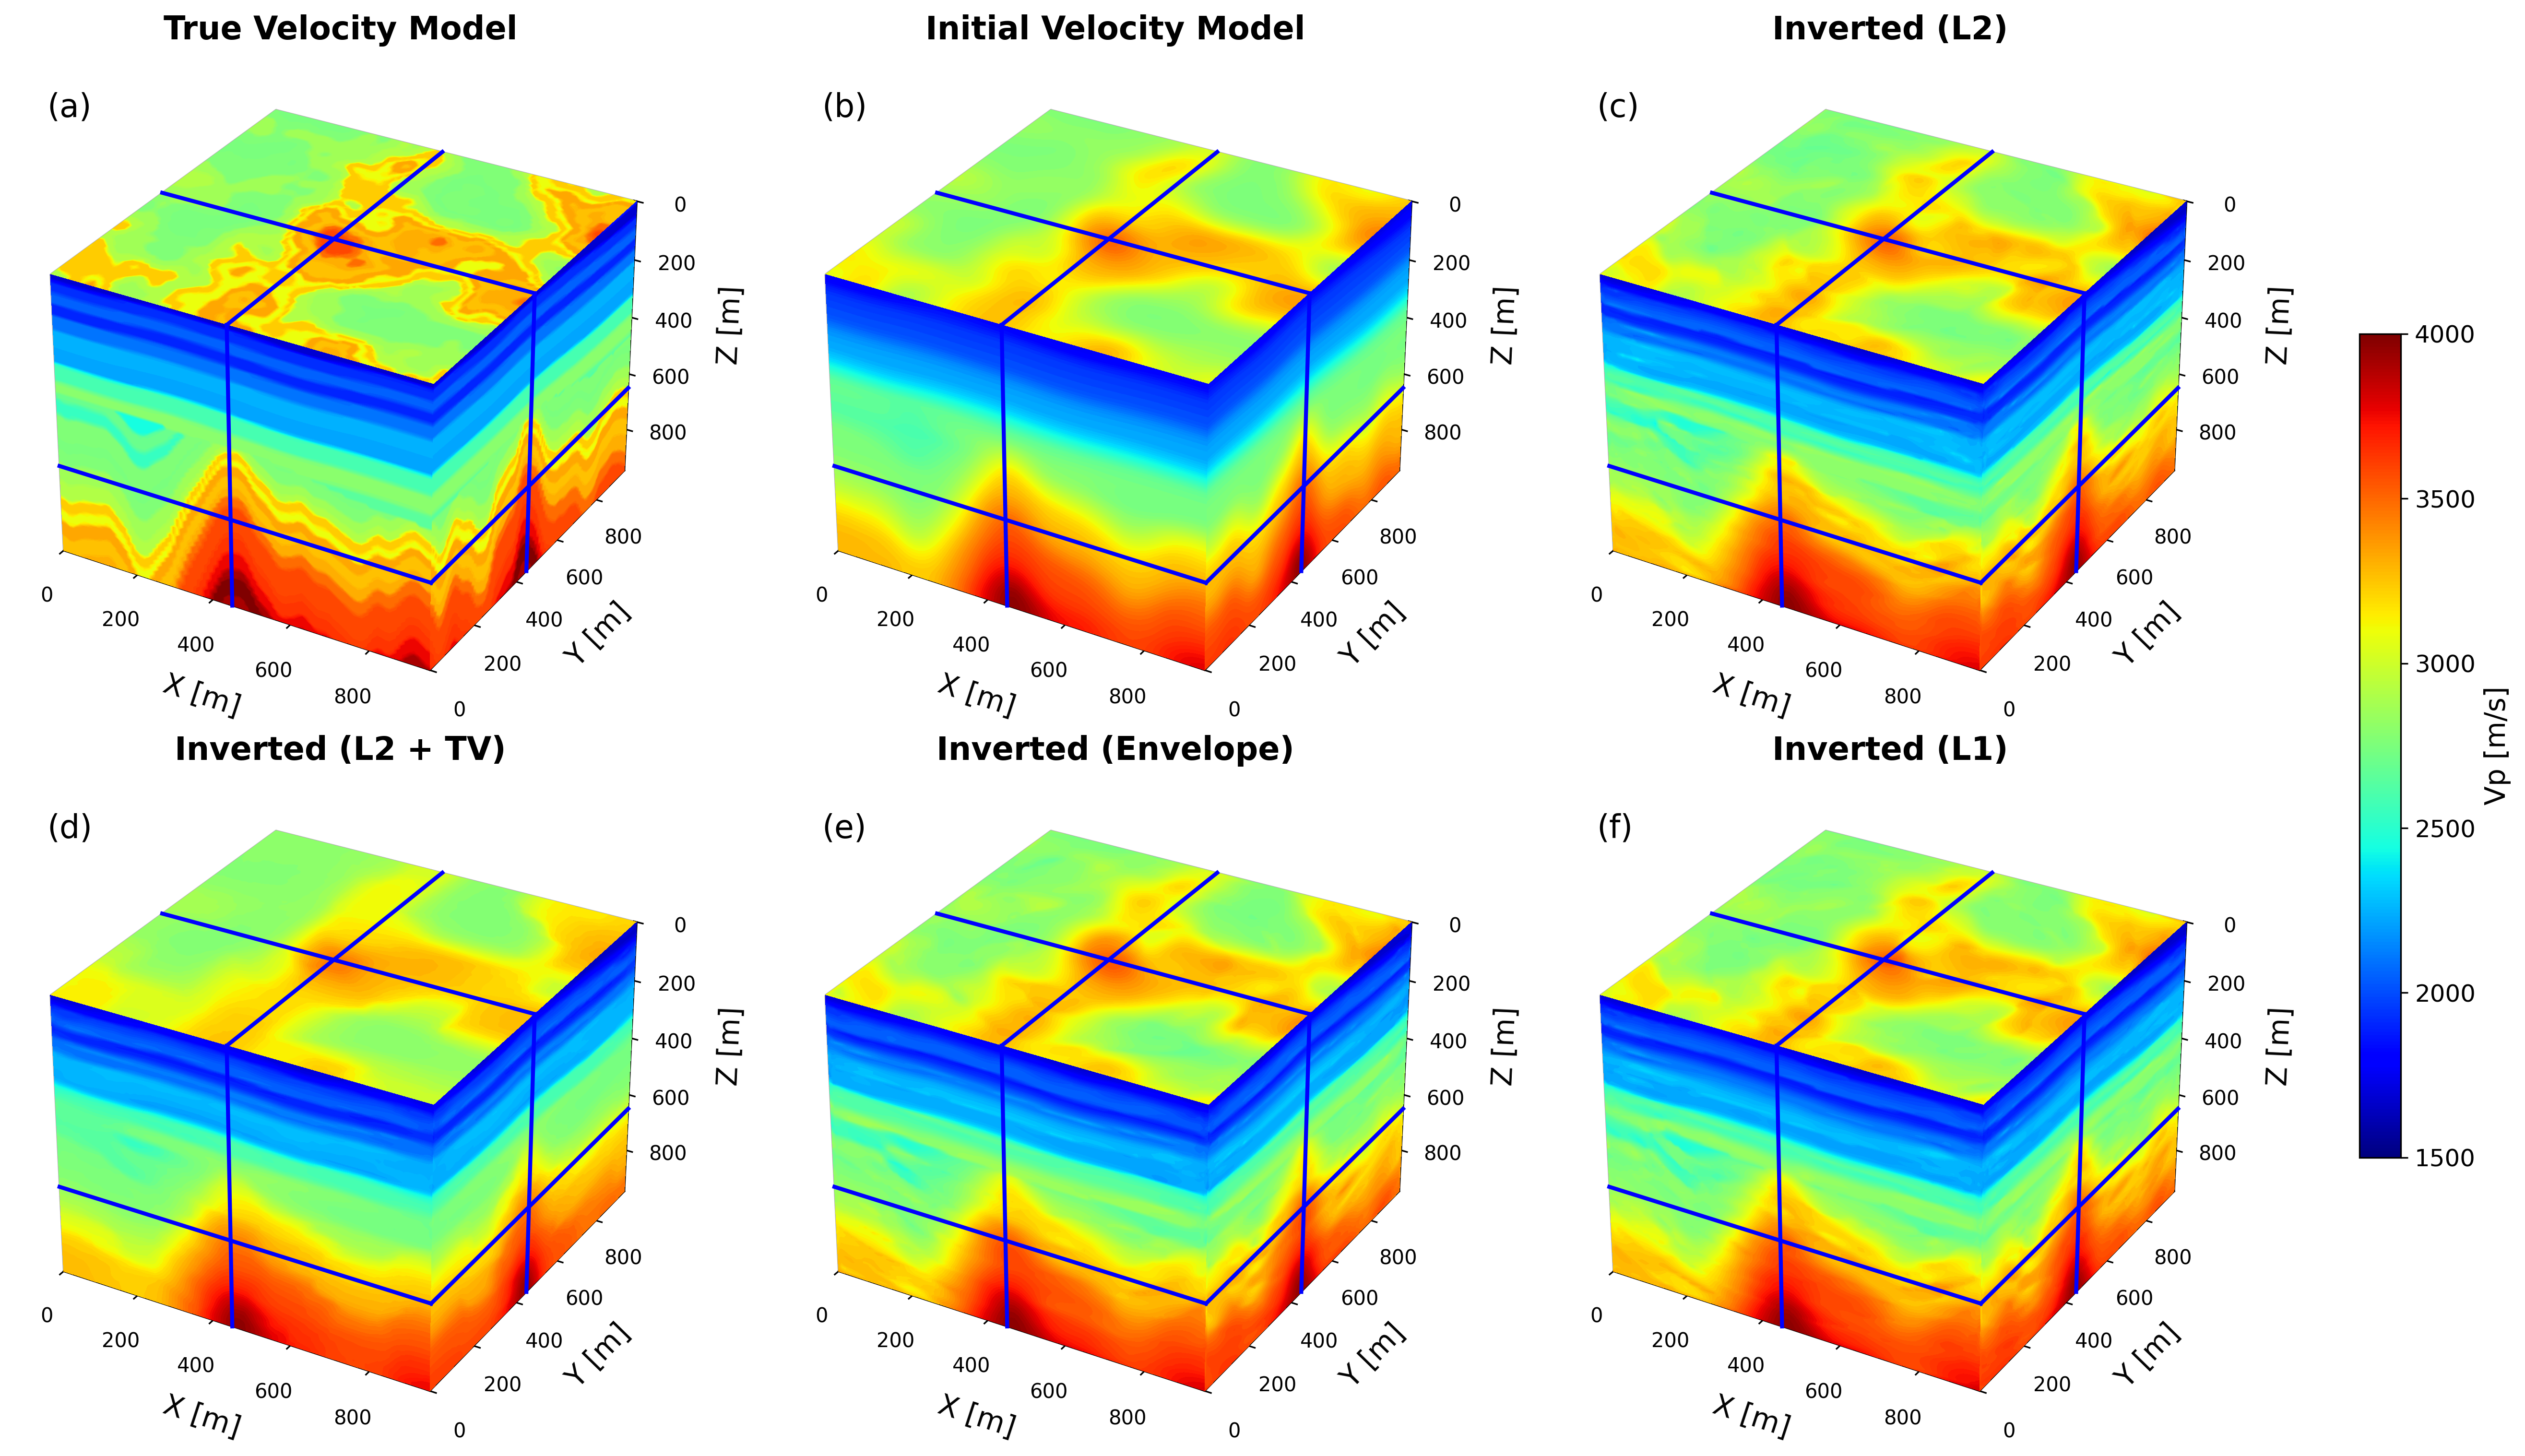

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

data = np.load("model9999_fwi_all.npz")
v_true1 = data["v_true"]
v_init1 = data["v_init"]
v_final_l2 = data["v_final_l2"]
v_final_l1 = data["v_final_l1"]
v_final_envelope = data["v_final_envelope"]
v_final_l2_tv = data["v_final_l2_tv"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "figure.dpi": 300,
})

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10),
    subplot_kw={"projection": "3d"},
    constrained_layout=True,
)

plot_items = [
    (v_true1, "True Velocity Model", "a"),
    (v_init1, "Initial Velocity Model", "b"),
    (v_final_l2, "Inverted (L2)", "c"),
    (v_final_l2_tv, "Inverted (L2 + TV)", "d"),
    (v_final_envelope, "Inverted (Envelope)", "e"),
    (v_final_l1, "Inverted (L1)", "f"),
]

for ax, (vol, title, letter) in zip(axes.ravel(), plot_items):
    ax.set_title(title, pad=10)
    plt.sca(ax)
    plot3d(
        vol,
        cmap="jet",
        vmin=1500,
        vmax=4000,
        dx=10.0,
        dy=10.0,
        dz=10.0,
        ifnewfig=False,
        ifinside=False,
        showf=False,
        close=False,
        frames=frames,
    )
    ax.tick_params(labelsize=10, pad=5)
    ax.set_xlabel("X [m]", labelpad=10)
    ax.set_ylabel("Y [m]", labelpad=10)
    ax.set_zlabel("Z [m]", labelpad=10)
    ax.text2D(0.05, 0.95, f"({letter})", transform=ax.transAxes, fontsize=16, va="top", ha="left", zorder=10)
    ax.set_rasterized(True)

norm = mcolors.Normalize(vmin=1500, vmax=4000)
sm = cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="vertical", shrink=0.6, pad=0.05)
cbar.set_label("Vp [m/s]", fontsize=14)

# plt.savefig("model9999-fwi.pdf", dpi=300, bbox_inches="tight")
plt.show()
